# Импорт библиотек

In [1]:
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Настройки для воспроизводимости

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cpu')

# Настройки гиперпараметров

In [3]:
BATCH_SIZE = 128
EPOCHS = 10
VAL_SIZE = 10000
TEST_BATCH_SIZE = 256

# Загрузка и подготовка MNIST

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),   # преобразует в tensor и делит значения на 255 -> [0,1]
])

In [5]:
full_train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

In [6]:
test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [7]:
train_size = len(full_train_dataset) - VAL_SIZE
val_size = VAL_SIZE

In [8]:
train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

In [9]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=TEST_BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=TEST_BATCH_SIZE, shuffle=False)

In [10]:
print(f"Размер train: {len(train_dataset)}")
print(f"Размер val:   {len(val_dataset)}")
print(f"Размер test:  {len(test_dataset)}")

Размер train: 50000
Размер val:   10000
Размер test:  10000


# Визуализация нескольких примеров

In [11]:
def show_samples(dataset, n=8):
    fig, axes = plt.subplots(1, n, figsize=(14, 3))
    for i in range(n):
        image, label = dataset[i]
        axes[i].imshow(image.squeeze(0), cmap="gray")
        axes[i].set_title(f"Label: {label}")
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

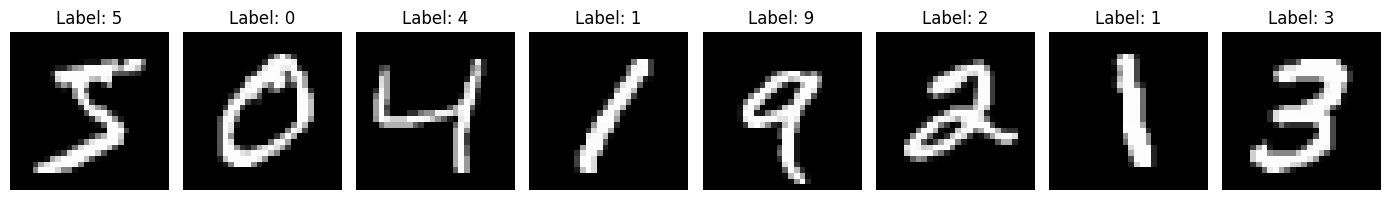

In [12]:
show_samples(full_train_dataset, n=8)

# Универсальная MLP-модель

In [13]:
class MLP(nn.Module):
    def __init__(self, input_size=28 * 28, hidden_layers=None, output_size=10, activation="relu", dropout=0.0):
        super().__init__()

        if hidden_layers is None:
            hidden_layers = [128]

        activation_map = {
            "relu": nn.ReLU,
            "tanh": nn.Tanh,
            "sigmoid": nn.Sigmoid,
            "leaky_relu": nn.LeakyReLU,
        }

        if activation not in activation_map:
            raise ValueError(f"Неизвестная функция активации: {activation}")

        act_layer = activation_map[activation]

        layers = []
        prev_size = input_size

        for hidden_size in hidden_layers:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(act_layer())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_size = hidden_size

        layers.append(nn.Linear(prev_size, output_size))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten: [batch, 1, 28, 28] -> [batch, 784]
        return self.network(x)

Метрики

In [14]:
def calculate_accuracy(outputs, labels):
    preds = torch.argmax(outputs, dim=1)
    correct = (preds == labels).sum().item()
    return correct / labels.size(0)

In [15]:
def evaluate_model(model, dataloader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)

            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc, np.array(all_labels), np.array(all_preds)

Обучение одной модели

In [16]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10, model_name="Model"):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
    }

    best_val_acc = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        model.train()

        running_loss = 0.0
        running_correct = 0
        running_samples = 0

        for images, labels in train_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            running_correct += (preds == labels).sum().item()
            running_samples += labels.size(0)

        train_loss = running_loss / running_samples
        train_acc = running_correct / running_samples

        val_loss, val_acc, _, _ = evaluate_model(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_weights = copy.deepcopy(model.state_dict())

        print(
            f"{model_name} | Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

    model.load_state_dict(best_model_weights)
    return model, history

Описание трех моделей

In [17]:
models_config = {
    "MLP_1_ReLU_Adam": {
        "model": MLP(hidden_layers=[128], activation="relu", dropout=0.0).to(DEVICE),
        "optimizer": lambda params: optim.Adam(params, lr=0.001),
    },
    "MLP_2_Tanh_SGD": {
        "model": MLP(hidden_layers=[256, 128], activation="tanh", dropout=0.0).to(DEVICE),
        "optimizer": lambda params: optim.SGD(params, lr=0.01, momentum=0.9),
    },
    "MLP_3_LeakyReLU_RMSprop": {
        "model": MLP(hidden_layers=[512, 256, 128], activation="leaky_relu", dropout=0.2).to(DEVICE),
        "optimizer": lambda params: optim.RMSprop(params, lr=0.001),
    },
}

In [18]:
criterion = nn.CrossEntropyLoss()
results = {}
trained_models = {}

In [19]:
for model_name, config in models_config.items():
    print("=" * 80)
    print(f"Обучение модели: {model_name}")

    model = config["model"]
    optimizer = config["optimizer"](model.parameters())

    trained_model, history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        epochs=EPOCHS,
        model_name=model_name
    )

    test_loss, test_acc, y_true, y_pred = evaluate_model(trained_model, test_loader, criterion)

    results[model_name] = {
        "history": history,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "y_true": y_true,
        "y_pred": y_pred,
    }
    trained_models[model_name] = trained_model

    print(f"{model_name} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

Обучение модели: MLP_1_ReLU_Adam
MLP_1_ReLU_Adam | Epoch [1/10] | Train Loss: 0.4461 | Train Acc: 0.8827 | Val Loss: 0.2592 | Val Acc: 0.9267
MLP_1_ReLU_Adam | Epoch [2/10] | Train Loss: 0.2119 | Train Acc: 0.9405 | Val Loss: 0.1936 | Val Acc: 0.9444
MLP_1_ReLU_Adam | Epoch [3/10] | Train Loss: 0.1531 | Train Acc: 0.9566 | Val Loss: 0.1602 | Val Acc: 0.9535
MLP_1_ReLU_Adam | Epoch [4/10] | Train Loss: 0.1195 | Train Acc: 0.9664 | Val Loss: 0.1366 | Val Acc: 0.9585
MLP_1_ReLU_Adam | Epoch [5/10] | Train Loss: 0.0966 | Train Acc: 0.9719 | Val Loss: 0.1213 | Val Acc: 0.9641
MLP_1_ReLU_Adam | Epoch [6/10] | Train Loss: 0.0811 | Train Acc: 0.9770 | Val Loss: 0.1137 | Val Acc: 0.9653
MLP_1_ReLU_Adam | Epoch [7/10] | Train Loss: 0.0681 | Train Acc: 0.9802 | Val Loss: 0.1048 | Val Acc: 0.9688
MLP_1_ReLU_Adam | Epoch [8/10] | Train Loss: 0.0575 | Train Acc: 0.9835 | Val Loss: 0.0996 | Val Acc: 0.9702
MLP_1_ReLU_Adam | Epoch [9/10] | Train Loss: 0.0490 | Train Acc: 0.9863 | Val Loss: 0.0989 | Va

In [20]:
def plot_training_histories(results):
    epochs_range = range(1, EPOCHS + 1)

    plt.figure(figsize=(14, 5))
    for model_name, result in results.items():
        plt.plot(epochs_range, result["history"]["train_loss"], label=f"{model_name} Train")
        plt.plot(epochs_range, result["history"]["val_loss"], linestyle="--", label=f"{model_name} Val")
    plt.title("Сравнение Loss")
    plt.xlabel("Эпоха")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(14, 5))
    for model_name, result in results.items():
        plt.plot(epochs_range, result["history"]["train_acc"], label=f"{model_name} Train")
        plt.plot(epochs_range, result["history"]["val_acc"], linestyle="--", label=f"{model_name} Val")
    plt.title("Сравнение Accuracy")
    plt.xlabel("Эпоха")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

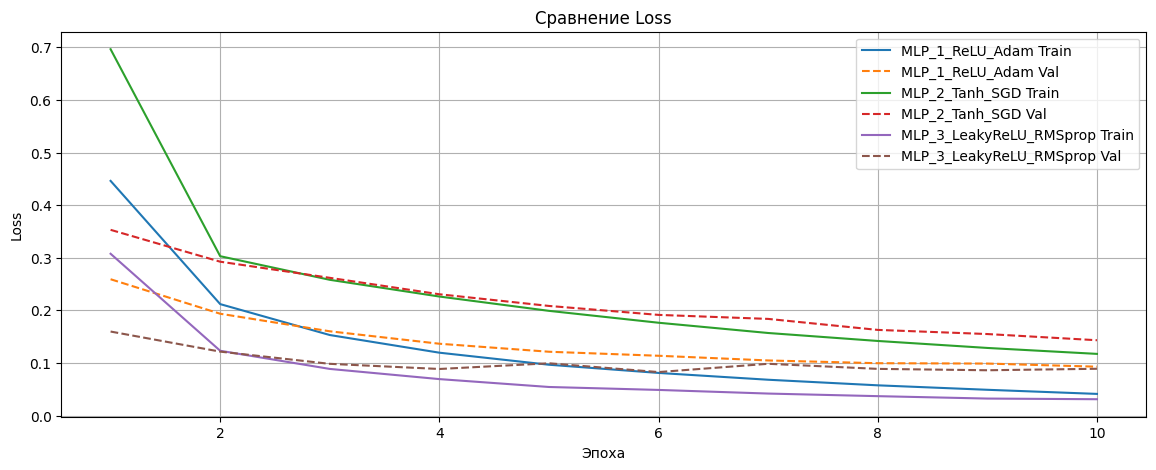

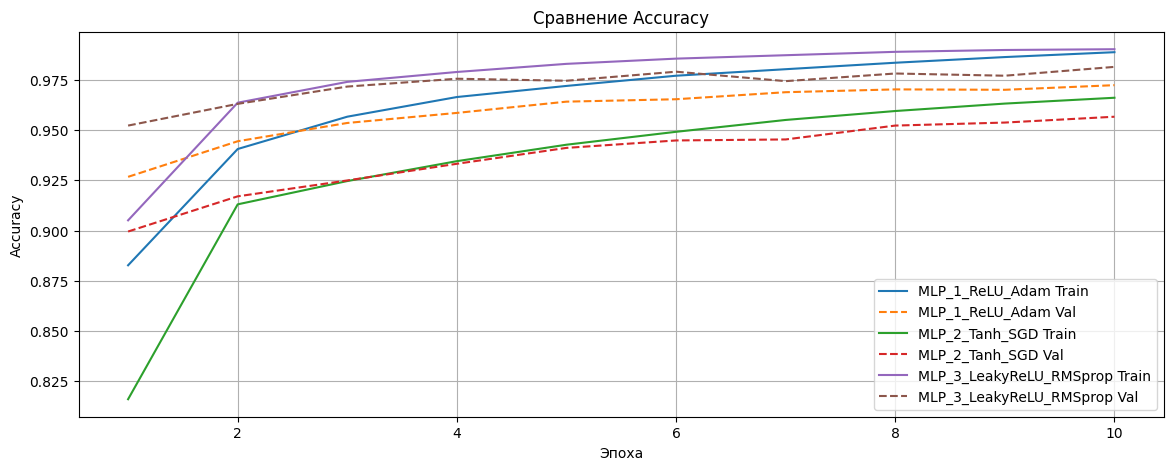

In [21]:
plot_training_histories(results)

**Вывод**:
- у всех моделей ошибка убывает по мере обучения
- модель MLP_3_LeakyReLU_RMSprop быстрее остальных снижает loss и выходит на наименьшие значения
- модель MLP_2_Tanh_SGD обучается заметно медленнее и сохраняет более высокий loss даже к 10-й эпохе
- все модели уверенно обучаются и достигают высокой точности
- MLP_3_LeakyReLU_RMSprop с первых эпох показывает наиболее быстрый рост качества
- MLP_1_ReLU_Adam тоже даёт сильный результат и близка к лучшей модели
- MLP_2_Tanh_SGD уступает двум другим на протяжении почти всего обучения

**Вывод**:
- у всех моделей ошибка убывает по мере обучения
- модель MLP_3_LeakyReLU_RMSprop быстрее остальных снижает loss и выходит на наименьшие значения
- модель MLP_2_Tanh_SGD обучается заметно медленнее и сохраняет более высокий loss даже к 10-й эпохе
- все модели уверенно обучаются и достигают высокой точности
- MLP_3_LeakyReLU_RMSprop с первых эпох показывает наиболее быстрый рост качества
- MLP_1_ReLU_Adam тоже даёт сильный результат и близка к лучшей модели
- MLP_2_Tanh_SGD уступает двум другим на протяжении почти всего обучения

In [22]:
print("\n" + "=" * 80)
print("Итоговые результаты на тестовой выборке:")
print("=" * 80)
sorted_results = sorted(results.items(), key=lambda x: x[1]["test_acc"], reverse=True)

for model_name, result in sorted_results:
    print(f"{model_name:25s} | Test Loss: {result['test_loss']:.4f} | Test Acc: {result['test_acc']:.4f}")



Итоговые результаты на тестовой выборке:
MLP_3_LeakyReLU_RMSprop   | Test Loss: 0.0766 | Test Acc: 0.9821
MLP_1_ReLU_Adam           | Test Loss: 0.0799 | Test Acc: 0.9763
MLP_2_Tanh_SGD            | Test Loss: 0.1269 | Test Acc: 0.9625


Лучшей оказалась модель MLP_3_LeakyReLU_RMSprop

Confusion Matrix

In [23]:
best_model_name = sorted_results[0][0]
best_result = results[best_model_name]

In [24]:
print(f"\nЛучшая модель: {best_model_name}")
print(classification_report(best_result["y_true"], best_result["y_pred"], digits=4))


Лучшая модель: MLP_3_LeakyReLU_RMSprop
              precision    recall  f1-score   support

           0     0.9898    0.9857    0.9877       980
           1     0.9920    0.9885    0.9903      1135
           2     0.9723    0.9874    0.9798      1032
           3     0.9910    0.9802    0.9856      1010
           4     0.9708    0.9817    0.9762       982
           5     0.9810    0.9843    0.9827       892
           6     0.9874    0.9812    0.9843       958
           7     0.9825    0.9835    0.9830      1028
           8     0.9784    0.9764    0.9774       974
           9     0.9751    0.9713    0.9732      1009

    accuracy                         0.9821     10000
   macro avg     0.9820    0.9820    0.9820     10000
weighted avg     0.9821    0.9821    0.9821     10000



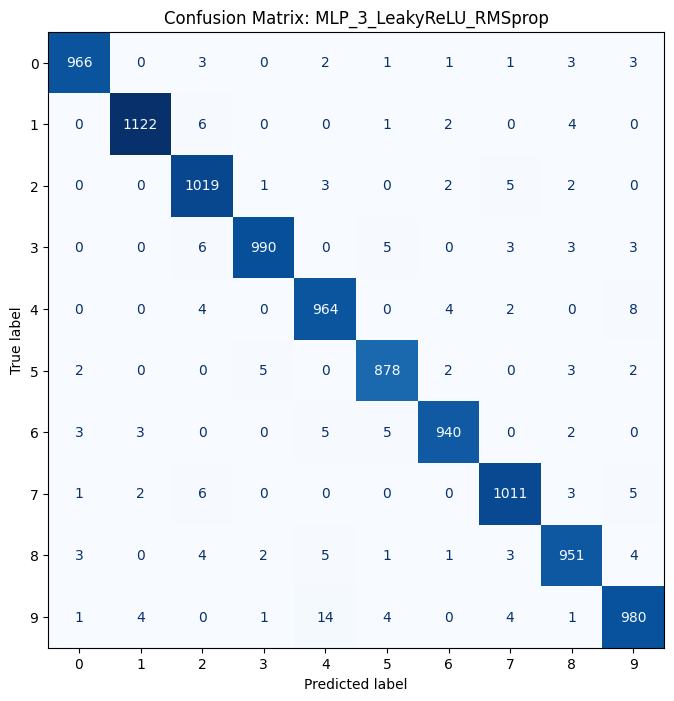

In [25]:
cm = confusion_matrix(best_result["y_true"], best_result["y_pred"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()

**Вывод**:
- У лучшей модели почти все значения сосредоточены на главной диагонали, а это значит, что большинство цифр классифицируются правильно
- Ошибки встречаются редко и в основном связаны с визуально похожими цифрами
- Это нормально для MNIST, потому что часть рукописных цифр действительно выглядит неоднозначно

Визуализация ошибок лучшей модели

In [26]:
def show_misclassified_examples(model, dataloader, max_images=10):
    model.eval()
    misclassified = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            for img, true_label, pred_label in zip(images, labels, preds):
                if true_label != pred_label:
                    misclassified.append((img.cpu(), true_label.cpu().item(), pred_label.cpu().item()))
                if len(misclassified) >= max_images:
                    break

            if len(misclassified) >= max_images:
                break

    if len(misclassified) == 0:
        print("Ошибок не найдено.")
        return

    cols = 5
    rows = int(np.ceil(len(misclassified) / cols))
    plt.figure(figsize=(15, 3 * rows))

    for i, (img, true_label, pred_label) in enumerate(misclassified):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img.squeeze(0), cmap="gray")
        plt.title(f"T: {true_label}, P: {pred_label}")
        plt.axis("off")

    plt.suptitle(f"Ошибки классификации: {best_model_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

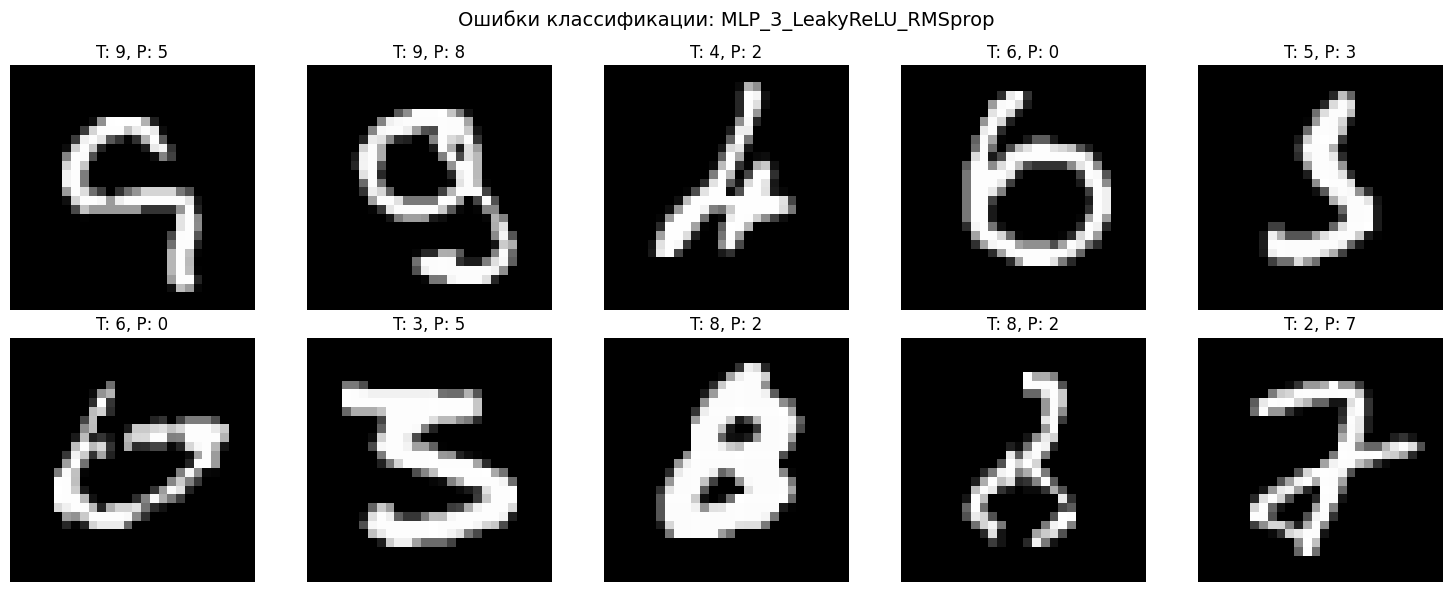

In [27]:
show_misclassified_examples(trained_models[best_model_name], test_loader, max_images=10)